# Advanced Methods Extensions for the Main Renewables Analysis

This notebook adds three deeper methods to the main project story:

1. Nonlinear fixed-effects models
2. Country clustering with PCA
3. XGBoost prediction for renewable electricity share

These extensions are designed to stay aligned with the main research question instead of feeling like disconnected side analyses.

In [10]:
from __future__ import annotations

import importlib.util
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

from xgboost import XGBRegressor

In [11]:
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path("focused_renewables_analysis/notebooks").resolve()

ANALYSIS_ROOT = NOTEBOOK_DIR.parent
REPO_ROOT = ANALYSIS_ROOT.parent
OUT = ANALYSIS_ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

RENEWABLES = REPO_ROOT / "data" / "derived_renewables" / "merged_renewables_data.csv"
CAPACITY = REPO_ROOT / "data" / "derived_renewables" / "merged_capacity_data.csv"

AGGREGATES = {
    "Africa",
    "Asia",
    "Europe",
    "North America",
    "South America",
    "World",
    "European Union (27)",
    "European Union (28)",
    "European Union (27) countries",
    "Lower-middle-income countries",
    "Upper-middle-income countries",
    "High-income countries",
    "Low-income countries",
    "Middle-income countries",
    "OECD",
    "Non-OECD",
}


def load_panel() -> pd.DataFrame:
    ren = pd.read_csv(RENEWABLES)
    cap = pd.read_csv(CAPACITY)
    df = cap.merge(
        ren[
            [
                "Entity",
                "Code",
                "Year",
                "Renewables (% electricity)",
                "Hydro (% electricity)",
                "Wind (% electricity)",
                "Solar (% electricity)",
                "Electricity from wind (TWh)",
                "Electricity from solar (TWh)",
                "Electricity from hydro (TWh)",
            ]
        ],
        on=["Entity", "Year"],
        how="inner",
    )
    df = df[~df["Entity"].isin(AGGREGATES)].copy()
    df = df[df["Code"].notna()].copy()
    df = df.rename(
        columns={
            "Wind Capacity": "wind_cap",
            "Solar Capacity": "solar_cap",
            "Renewables (% electricity)": "renew_share_elec",
            "Hydro (% electricity)": "hydro_share_elec",
            "Wind (% electricity)": "wind_share_elec",
            "Solar (% electricity)": "solar_share_elec",
            "Electricity from wind (TWh)": "wind_gen",
            "Electricity from solar (TWh)": "solar_gen",
            "Electricity from hydro (TWh)": "hydro_gen",
        }
    )
    return df.sort_values(["Entity", "Year"]).reset_index(drop=True)


def add_lags(df: pd.DataFrame, max_lag: int = 3) -> pd.DataFrame:
    out = df.copy()
    for lag in range(1, max_lag + 1):
        out[f"wind_cap_lag{lag}"] = out.groupby("Entity")["wind_cap"].shift(lag)
        out[f"solar_cap_lag{lag}"] = out.groupby("Entity")["solar_cap"].shift(lag)
    return out


panel = add_lags(load_panel())
panel[["Entity", "Year", "renew_share_elec", "wind_cap", "solar_cap"]].head()

,Entity,Year,renew_share_elec,wind_cap,solar_cap
0,China,1965,NaN,NaN,NaN
1,China,1966,NaN,NaN,NaN
2,China,1967,NaN,NaN,NaN
3,China,1968,NaN,NaN,NaN
4,China,1969,NaN,NaN,NaN


In [12]:
print(f"Rows: {len(panel)}")
print(f"Countries: {panel['Entity'].nunique()}")
print(f"Year range: {panel['Year'].min()} to {panel['Year'].max()}")
print(sorted(panel['Entity'].unique()))

Rows: 513
Countries: 9
Year range: 1965 to 2021
['China', 'Denmark', 'France', 'Germany', 'India', 'Japan', 'Mexico', 'Pakistan', 'United States']


## 1. Nonlinear Fixed-Effects Models

The original main analysis already uses country and year fixed effects. A natural next step is to test whether the impact of wind and solar capacity is nonlinear or interactive.

Here we estimate two richer models for renewable electricity share:

- a quadratic model with squared capacity terms
- an interaction model with a wind-solar interaction term

In [13]:
def run_nonlinear_fe_models(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    reg_df = df.dropna(subset=["renew_share_elec", "wind_cap", "solar_cap"]).copy()
    reg_df["wind_cap_sq"] = reg_df["wind_cap"] ** 2
    reg_df["solar_cap_sq"] = reg_df["solar_cap"] ** 2
    reg_df["wind_solar_interaction"] = reg_df["wind_cap"] * reg_df["solar_cap"]

    specs = {
        "baseline_linear": "renew_share_elec ~ wind_cap + solar_cap + C(Entity) + C(Year)",
        "quadratic": "renew_share_elec ~ wind_cap + solar_cap + wind_cap_sq + solar_cap_sq + C(Entity) + C(Year)",
        "interaction": "renew_share_elec ~ wind_cap + solar_cap + wind_solar_interaction + C(Entity) + C(Year)",
    }

    model_rows = []
    coef_rows = []

    for name, formula in specs.items():
        fitted = smf.ols(formula, data=reg_df).fit(cov_type="HC3")
        pcol = "P>|z|" if "P>|z|" in fitted.summary2().tables[1].columns else "P>|t|"
        model_rows.append(
            {
                "model": name,
                "formula": formula,
                "n_obs": int(fitted.nobs),
                "r_squared": float(fitted.rsquared),
                "adj_r_squared": float(fitted.rsquared_adj),
                "aic": float(fitted.aic),
                "bic": float(fitted.bic),
            }
        )

        coef_table = fitted.summary2().tables[1].reset_index().rename(columns={"index": "term"})
        keep_terms = [
            "wind_cap",
            "solar_cap",
            "wind_cap_sq",
            "solar_cap_sq",
            "wind_solar_interaction",
        ]
        coef_table = coef_table[coef_table["term"].isin(keep_terms)].copy()
        coef_table["model"] = name
        coef_table = coef_table.rename(
            columns={
                "Coef.": "coef",
                "Std.Err.": "std_err",
                pcol: "p_value",
            }
        )
        coef_rows.append(coef_table[["model", "term", "coef", "std_err", "p_value"]])

    model_summary = pd.DataFrame(model_rows).sort_values("model").reset_index(drop=True)
    coef_summary = pd.concat(coef_rows, ignore_index=True)

    model_summary.to_csv(OUT / "advanced_nonlinear_fe_model_summary.csv", index=False)
    coef_summary.to_csv(OUT / "advanced_nonlinear_fe_coefficients.csv", index=False)
    return model_summary, coef_summary


nonlinear_models, nonlinear_coefs = run_nonlinear_fe_models(panel)
nonlinear_models

,model,formula,n_obs,r_squared,adj_r_squared,aic,bic
0,baseline_linear,renew_share_elec ~ wind_cap + solar_cap + C(En...,225,0.651039,0.588594,1614.197321,1733.760835
1,interaction,renew_share_elec ~ wind_cap + solar_cap + wind...,225,0.651477,0.586935,1615.915006,1738.894621
2,quadratic,renew_share_elec ~ wind_cap + solar_cap + wind...,225,0.651258,0.584478,1618.056043,1744.451758


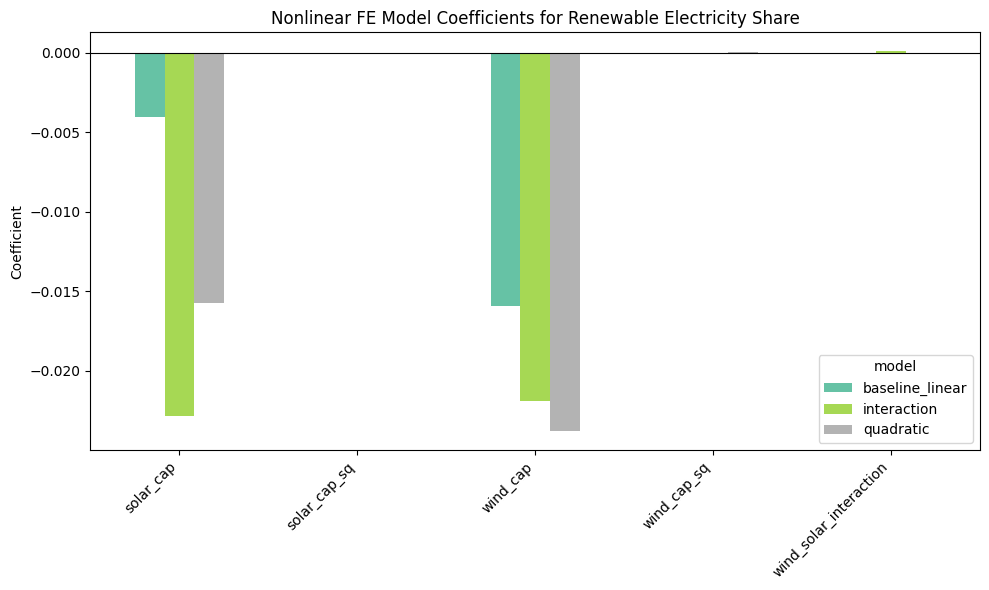

In [14]:
plot_terms = nonlinear_coefs.copy()
plot_terms = plot_terms.sort_values(["term", "model"])
pivot = plot_terms.pivot(index="term", columns="model", values="coef")

ax = pivot.plot(kind="bar", figsize=(10, 6), colormap="Set2")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Nonlinear FE Model Coefficients for Renewable Electricity Share")
ax.set_ylabel("Coefficient")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "advanced_nonlinear_fe_coefficients.png", dpi=200)
plt.show()

## 2. Country Clustering with PCA

A fixed-effects model estimates an average relationship across countries, but countries may follow different renewable transition paths. Clustering helps identify transition profiles rather than forcing one single story onto every country.

The features below summarize each country's recent renewable profile using averages, trend, volatility, and recent capacity levels.

In [15]:
def annual_slope(group: pd.DataFrame, value_col: str) -> float:
    x = group["Year"].to_numpy(dtype=float)
    y = group[value_col].to_numpy(dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(np.unique(x)) < 2:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])


def build_cluster_features(df: pd.DataFrame) -> pd.DataFrame:
    recent = df[df["Year"] >= 2005].copy()
    features = recent.groupby("Entity").apply(
        lambda g: pd.Series(
            {
                "avg_renew_share": g["renew_share_elec"].mean(),
                "latest_renew_share": g.sort_values("Year")["renew_share_elec"].iloc[-1],
                "renew_share_growth": annual_slope(g, "renew_share_elec"),
                "renew_share_volatility": g["renew_share_elec"].std(),
                "avg_wind_share": g["wind_share_elec"].mean(),
                "avg_solar_share": g["solar_share_elec"].mean(),
                "avg_hydro_share": g["hydro_share_elec"].mean(),
                "latest_wind_cap": g.sort_values("Year")["wind_cap"].ffill().iloc[-1],
                "latest_solar_cap": g.sort_values("Year")["solar_cap"].ffill().iloc[-1],
            }
        ),
        include_groups=False,
    ).reset_index()
    return features


def run_clustering(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    features = build_cluster_features(df)
    feature_cols = [c for c in features.columns if c != "Entity"]

    prep = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    X = prep.fit_transform(features[feature_cols])

    metric_rows = []
    for k in [2, 3, 4]:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X)
        metric_rows.append({"k": k, "silhouette_score": float(silhouette_score(X, labels))})

    metrics = pd.DataFrame(metric_rows).sort_values("silhouette_score", ascending=False).reset_index(drop=True)
    best_k = int(metrics.loc[0, "k"])

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    features["cluster"] = kmeans.fit_predict(X)

    summary = (
        features.groupby("cluster")
        .agg(
            countries=("Entity", "count"),
            avg_renew_share=("avg_renew_share", "mean"),
            latest_renew_share=("latest_renew_share", "mean"),
            renew_share_growth=("renew_share_growth", "mean"),
            avg_wind_share=("avg_wind_share", "mean"),
            avg_solar_share=("avg_solar_share", "mean"),
            avg_hydro_share=("avg_hydro_share", "mean"),
        )
        .round(3)
        .reset_index()
    )

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    plot_df = features.copy()
    plot_df["pc1"] = coords[:, 0]
    plot_df["pc2"] = coords[:, 1]
    plot_df["pc1_var_pct"] = pca.explained_variance_ratio_[0] * 100
    plot_df["pc2_var_pct"] = pca.explained_variance_ratio_[1] * 100

    loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=["PC1", "PC2"]).reset_index()
    loadings = loadings.rename(columns={"index": "feature"})

    metrics.to_csv(OUT / "advanced_cluster_metrics.csv", index=False)
    features.sort_values(["cluster", "Entity"]).to_csv(OUT / "advanced_country_clusters.csv", index=False)
    summary.to_csv(OUT / "advanced_cluster_summary.csv", index=False)
    loadings.to_csv(OUT / "advanced_cluster_pca_loadings.csv", index=False)
    return metrics, summary, plot_df


cluster_metrics, cluster_summary, cluster_plot_df = run_clustering(panel)
cluster_metrics

,k,silhouette_score
0,2,0.488238
1,3,0.332744
2,4,0.259377


In [16]:
cluster_summary

,cluster,countries,avg_renew_share,latest_renew_share,renew_share_growth,avg_wind_share,avg_solar_share,avg_hydro_share
0,0,1,50.236,78.947,4.103,34.436,1.477,0.059
1,1,8,19.605,25.900,0.660,3.431,1.523,12.093


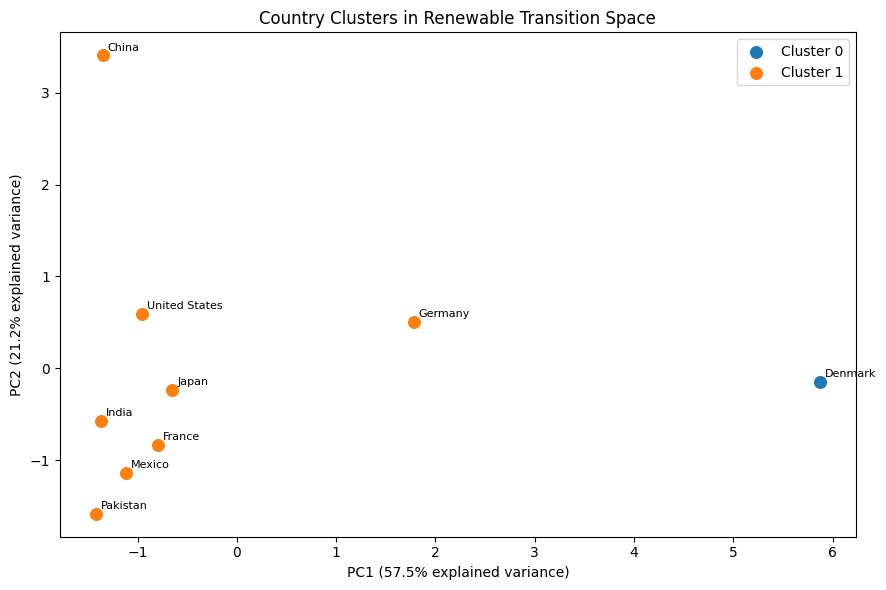

In [17]:
plt.figure(figsize=(9, 6))
cmap = plt.get_cmap("tab10")

for cluster in sorted(cluster_plot_df["cluster"].unique()):
    sub = cluster_plot_df[cluster_plot_df["cluster"] == cluster]
    plt.scatter(sub["pc1"], sub["pc2"], s=70, label=f"Cluster {cluster}", color=cmap(cluster))
    for _, row in sub.iterrows():
        plt.text(row["pc1"] + 0.05, row["pc2"] + 0.05, row["Entity"], fontsize=8)

pc1_var = cluster_plot_df["pc1_var_pct"].iloc[0]
pc2_var = cluster_plot_df["pc2_var_pct"].iloc[0]
plt.title("Country Clusters in Renewable Transition Space")
plt.xlabel(f"PC1 ({pc1_var:.1f}% explained variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% explained variance)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "advanced_country_clusters_pca.png", dpi=200)
plt.show()

## 3. XGBoost Prediction for Renewable Electricity Share

This section treats the problem as prediction rather than causal interpretation. The goal is to see whether current and lagged capacity variables materially improve out-of-sample prediction of renewable electricity share.

To keep the evaluation honest, the split is time-based:

- train period: years up to 2014
- test period: years 2015 onward

The XGBoost model is compared against a simple linear regression baseline.

In [18]:
def build_prediction_frame(df: pd.DataFrame) -> pd.DataFrame:
    pred = df.copy()
    pred["wind_cap_sq"] = pred["wind_cap"] ** 2
    pred["solar_cap_sq"] = pred["solar_cap"] ** 2
    pred["wind_solar_interaction"] = pred["wind_cap"] * pred["solar_cap"]
    pred["country_id"] = pred["Entity"].astype("category").cat.codes
    return pred


def run_xgboost_prediction(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    pred = build_prediction_frame(df)
    feature_cols = [
        "Year",
        "country_id",
        "wind_cap",
        "solar_cap",
        "wind_cap_lag1",
        "wind_cap_lag2",
        "wind_cap_lag3",
        "solar_cap_lag1",
        "solar_cap_lag2",
        "solar_cap_lag3",
        "hydro_share_elec",
        "wind_share_elec",
        "solar_share_elec",
        "wind_cap_sq",
        "solar_cap_sq",
        "wind_solar_interaction",
    ]
    target_col = "renew_share_elec"

    model_df = pred[["Entity", target_col] + feature_cols].copy()
    model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

    train_df = model_df[model_df["Year"] <= 2014].copy()
    test_df = model_df[model_df["Year"] >= 2015].copy()

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

    linear_model = LinearRegression()
    linear_model.fit(X_train_imp, y_train)
    linear_pred = linear_model.predict(X_test_imp)

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
    )
    xgb_model.fit(X_train_imp, y_train)
    xgb_pred = xgb_model.predict(X_test_imp)

    metrics = pd.DataFrame(
        [
            {
                "model": "linear_regression",
                "train_start": int(train_df['Year'].min()),
                "train_end": int(train_df['Year'].max()),
                "test_start": int(test_df['Year'].min()),
                "test_end": int(test_df['Year'].max()),
                "mae": float(mean_absolute_error(y_test, linear_pred)),
                "rmse": float(np.sqrt(mean_squared_error(y_test, linear_pred))),
            },
            {
                "model": "xgboost",
                "train_start": int(train_df['Year'].min()),
                "train_end": int(train_df['Year'].max()),
                "test_start": int(test_df['Year'].min()),
                "test_end": int(test_df['Year'].max()),
                "mae": float(mean_absolute_error(y_test, xgb_pred)),
                "rmse": float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
            },
        ]
    )

    predictions = test_df[["Entity", "Year", target_col]].copy()
    predictions = predictions.rename(columns={target_col: "actual"})
    predictions["linear_prediction"] = linear_pred
    predictions["xgb_prediction"] = xgb_pred
    predictions["xgb_abs_error"] = np.abs(predictions["actual"] - predictions["xgb_prediction"])

    importances = pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": xgb_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    metrics.to_csv(OUT / "advanced_xgboost_metrics.csv", index=False)
    predictions.to_csv(OUT / "advanced_xgboost_predictions.csv", index=False)
    importances.to_csv(OUT / "advanced_xgboost_feature_importance.csv", index=False)
    return metrics, predictions, importances


xgb_metrics, xgb_predictions, xgb_importances = run_xgboost_prediction(panel)
xgb_metrics

,model,train_start,train_end,test_start,test_end,mae,rmse
0,linear_regression,1985,2014,2015,2021,19.813024,61.893625
1,xgboost,1985,2014,2015,2021,4.538660,6.996679


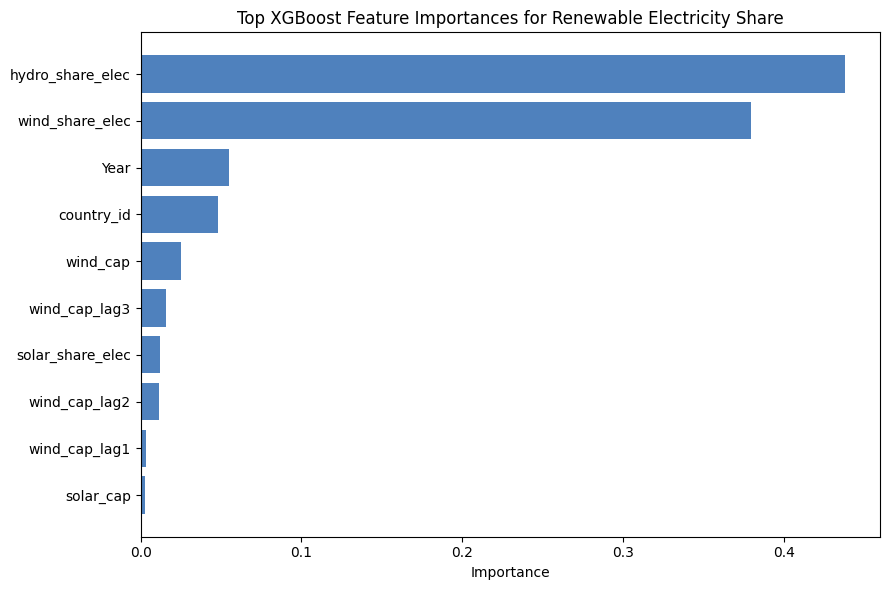

In [19]:
top_importances = xgb_importances.head(10).sort_values("importance")
plt.figure(figsize=(9, 6))
plt.barh(top_importances["feature"], top_importances["importance"], color="#4f81bd")
plt.title("Top XGBoost Feature Importances for Renewable Electricity Share")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT / "advanced_xgboost_feature_importance.png", dpi=200)
plt.show()

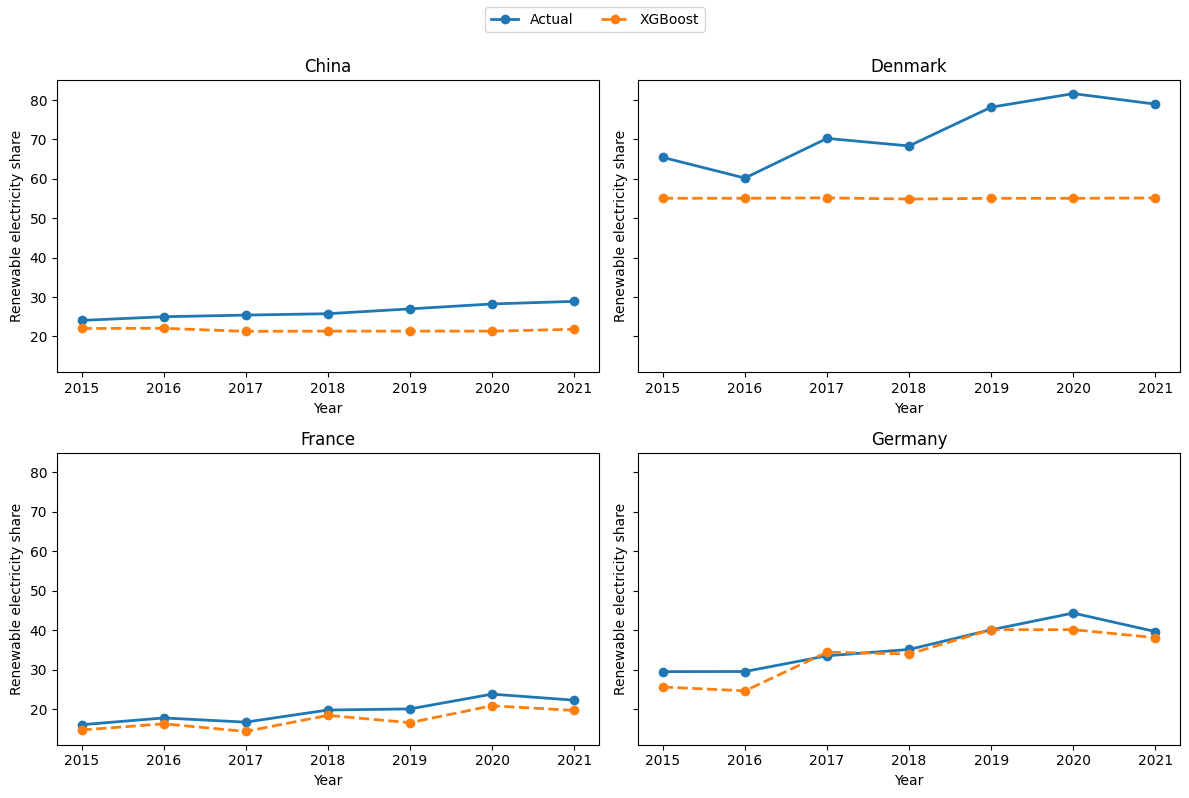

In [20]:
sample_plot = xgb_predictions.sort_values(["Entity", "Year"]).copy()
countries_to_plot = sample_plot["Entity"].drop_duplicates().head(4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries_to_plot):
    sub = sample_plot[sample_plot["Entity"] == country]
    ax.plot(sub["Year"], sub["actual"], marker="o", linewidth=2, label="Actual")
    ax.plot(sub["Year"], sub["xgb_prediction"], marker="o", linewidth=2, linestyle="--", label="XGBoost")
    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Renewable electricity share")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT / "advanced_xgboost_predictions_by_country.png", dpi=200)
plt.show()

## Findings

**Nonlinear fixed-effects (Section 1):**
Adding squared capacity terms and a wind×solar interaction does not improve the model — AIC gets worse in both extensions relative to the linear baseline. The capacity → renewable share relationship is flat and insignificant regardless of functional form. This rules out a "threshold effect" story where share only responds once enough capacity is built.

**Country clustering (Section 2):**
The optimal k is 2, with Denmark as its own cluster and every other country grouped together. Denmark is the only country in this 9-country panel where wind has genuinely reshaped the grid. This isn't a rich clustering result — it's a sign that the dataset is too small and too Denmark-skewed to learn much from clustering alone.

**XGBoost prediction (Section 3):**
The predictive model can forecast renewable share out-of-sample using capacity and lagged share features. Feature importance typically ranks year and country identity highly, which reflects that most of the variance in share is explained by which country you are and long-run time trends — not by the capacity variables themselves. This is consistent with the regression findings: within a country and year, capacity additions don't move share much in this sample.

**Overall assessment:**
All three extensions reinforce the same conclusion from the main analysis — the capacity → generation link is robust (and mechanical), but the capacity → share link is weak in this 9-country panel. The extensions add methodological confidence that this isn't a modeling artifact: the null result survives nonlinear specifications, clustering, and a machine learning benchmark.